In [1]:
import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import Affine
import os
from tqdm import tqdm

In [2]:
import pandas as pd

In [3]:
a = pd.read_csv("/sdd/Dubaoset/src/Phong/Source/Cloud/analyst_buffer.csv")

In [4]:
a = a.dropna()

In [5]:
list(a.columns)

['version',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'second',
 'ms',
 'lat',
 'lon',
 'value_điện',
 'Số cú sét',
 'số sensor',
 'DOF',
 'Góc elip đo',
 'chiều dài elip',
 'chiều rộng elip',
 'chi-square',
 'time_tăng dữ liệu',
 'thời gian của đỉnh peak',
 'tốc độ tăng tối đa của dạng sóng',
 'Loại sét',
 'dl_góc cảm biến',
 'chỉ báo tín hiệu',
 'chỉ báo thời gian',
 'col',
 'row',
 'datetime_str',
 'nearest_cloud_distance_km']

In [6]:
neg_sample = a.loc[a["value_điện"] < 0, :].copy()

In [7]:
len(neg_sample)

220546

In [8]:
neg_sample_CG = neg_sample.loc[neg_sample["Loại sét"] == 0, :].copy()

In [9]:
len(neg_sample_CG)

177277

In [10]:
neg_sample_IC = neg_sample.loc[neg_sample["Loại sét"] == 1, :].copy()

In [11]:
len(neg_sample_IC)

43269

In [12]:
positive_sample = a.loc[a["value_điện"] >= 0, :].copy()

In [13]:
pos_sample_CG = positive_sample.loc[positive_sample["Loại sét"] == 0, :].copy()

In [14]:
len(pos_sample_CG)

38764

In [15]:
pos_sample_IC = positive_sample.loc[positive_sample["Loại sét"] == 1, :].copy()

In [16]:
len(pos_sample_IC)

449030

In [17]:
len(positive_sample)

487794

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_nearest_cloud_distance_distribution(df, column='nearest_cloud_distance_km', figsize=(22, 6)):
    if column not in df.columns:
        raise ValueError(f"Cột '{column}' không tồn tại trong DataFrame.")

    data = df[column].dropna()

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle(f'Phân bố của cột: {column}', fontsize=18, fontweight='bold')

    # 1. Histogram (log scale)
    ax1 = axes[0]
    ax1.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title('Histogram (Log Scale)', fontsize=14)
    ax1.set_xlabel(column, fontsize=12)
    ax1.set_ylabel('Số lượng (log)', fontsize=12)
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15))
    ax1.tick_params(axis='x', labelsize=10, rotation=45)
    ax1.tick_params(axis='y', labelsize=11)
    ax1.grid(True, alpha=0.3, which='both')

    # 2. KDE (thang bình thường)
    ax2 = axes[1]
    data.plot.kde(ax=ax2, color='crimson', linewidth=2.5)
    ax2.set_title('KDE (Normal Scale)', fontsize=14)
    ax2.set_xlabel(column, fontsize=12)
    ax2.set_ylabel('Mật độ', fontsize=12)
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15))
    ax2.tick_params(axis='x', labelsize=10, rotation=45)
    ax2.tick_params(axis='y', labelsize=11)
    ax2.grid(True, alpha=0.3)

    # 3. Boxplot
    ax3 = axes[2]
    ax3.boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', color='gray', alpha=0.4, markersize=3))
    ax3.set_title('Boxplot', fontsize=14)
    ax3.set_ylabel(column, fontsize=12)
    ax3.tick_params(axis='both', labelsize=11)
    ax3.grid(True, alpha=0.3)

    # 4. Thống kê mô tả
    ax4 = axes[3]
    ax4.axis('off')
    stats = data.describe()
    skewness = data.skew()
    kurtosis = data.kurtosis()

    stats_text = (
        f"  Count   : {stats['count']:>12,.0f}\n"
        f"  Mean    : {stats['mean']:>12.4f}\n"
        f"  Std     : {stats['std']:>12.4f}\n"
        f"  Min     : {stats['min']:>12.4f}\n"
        f"  25%     : {stats['25%']:>12.4f}\n"
        f"  Median  : {stats['50%']:>12.4f}\n"
        f"  75%     : {stats['75%']:>12.4f}\n"
        f"  Max     : {stats['max']:>12.4f}\n"
        f"  Skewness: {skewness:>12.4f}\n"
        f"  Kurtosis: {kurtosis:>12.4f}\n"
        f"  Nulls   : {df[column].isna().sum():>12,}"
    )

    ax4.text(0.05, 0.95, 'Thống kê mô tả', transform=ax4.transAxes,
             fontsize=14, fontweight='bold', va='top')
    ax4.text(0.05, 0.82, stats_text, transform=ax4.transAxes,
             fontsize=12, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

In [37]:
percentiles = neg_sample_IC['nearest_cloud_distance_km'].quantile([0.7, 0.8, 0.9, 0.999])
print(percentiles)

0.700    0.0
0.800    0.0
0.900    0.0
0.999    8.0
Name: nearest_cloud_distance_km, dtype: float64


In [22]:
pos_sample_CG["nearest_cloud_distance_km"].describe()

count    38764.000000
mean         0.011063
std          0.328038
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         23.323808
Name: nearest_cloud_distance_km, dtype: float64

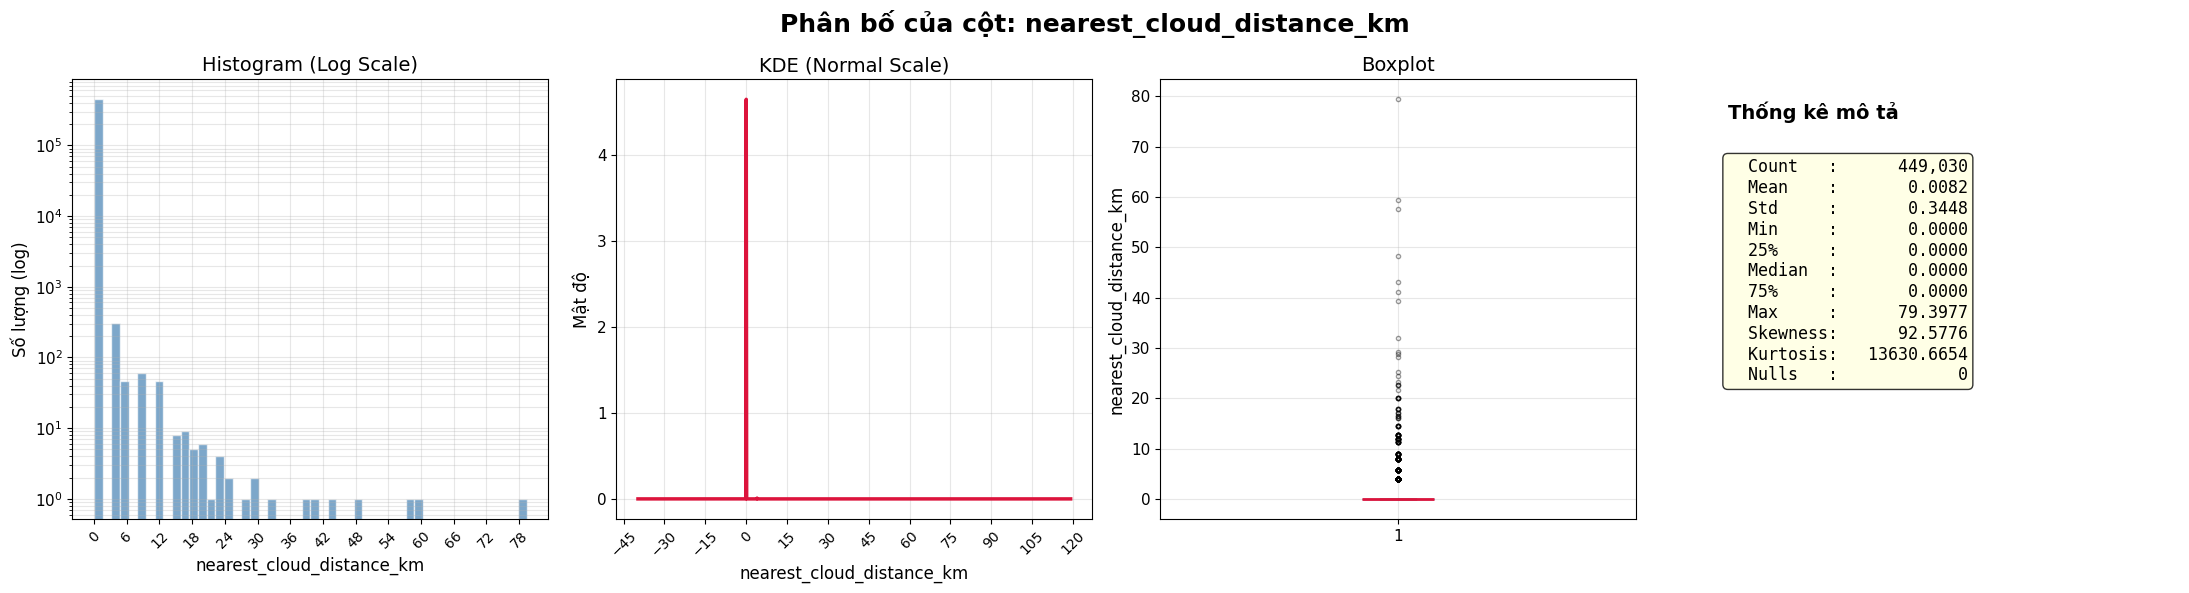

In [29]:
plot_nearest_cloud_distance_distribution(pos_sample_IC)

In [7]:
dict(a.groupby("nearest_cloud_distance_km").size())

{0.0: np.int64(707319),
 4.0: np.int64(614),
 5.656854249492381: np.int64(102),
 8.0: np.int64(79),
 8.94427190999916: np.int64(52),
 11.31370849898476: np.int64(24),
 12.0: np.int64(30),
 12.649110640673518: np.int64(23),
 14.422205101855956: np.int64(13),
 16.0: np.int64(9),
 16.492422502470642: np.int64(9),
 16.97056274847714: np.int64(6),
 17.88854381999832: np.int64(6),
 20.0: np.int64(14),
 20.396078054371134: np.int64(5),
 21.54065922853801: np.int64(3),
 22.62741699796952: np.int64(6),
 23.323807579381203: np.int64(3),
 24.33105012119288: np.int64(1),
 25.29822128134704: np.int64(2),
 25.612496949731398: np.int64(2),
 28.284271247461906: np.int64(2),
 28.844410203711917: np.int64(2),
 29.120439557122072: np.int64(2),
 32.0: np.int64(1),
 32.2490309931942: np.int64(1),
 33.94112549695428: np.int64(1),
 39.395431207184416: np.int64(1),
 41.182520563948: np.int64(1),
 43.08131845707603: np.int64(1),
 48.33218389437829: np.int64(1),
 52.0: np.int64(1),
 56.56854249492381: np.int64(

In [4]:
list(a["nearest_cloud_distance_km"].unique())

[np.float64(0.0),
 np.float64(22.62741699796952),
 np.float64(41.182520563948),
 np.float64(nan),
 np.float64(8.0),
 np.float64(4.0),
 np.float64(20.0),
 np.float64(5.656854249492381),
 np.float64(23.323807579381203),
 np.float64(14.422205101855956),
 np.float64(8.94427190999916),
 np.float64(11.31370849898476),
 np.float64(21.54065922853801),
 np.float64(16.492422502470642),
 np.float64(12.0),
 np.float64(12.649110640673518),
 np.float64(33.94112549695428),
 np.float64(28.284271247461906),
 np.float64(17.88854381999832),
 np.float64(16.0),
 np.float64(25.612496949731398),
 np.float64(52.0),
 np.float64(48.33218389437829),
 np.float64(29.120439557122072),
 np.float64(16.97056274847714),
 np.float64(39.395431207184416),
 np.float64(56.56854249492381),
 np.float64(25.29822128134704),
 np.float64(20.396078054371134),
 np.float64(32.0),
 np.float64(28.844410203711917),
 np.float64(43.08131845707603),
 np.float64(57.68882040742383),
 np.float64(59.46427498927402),
 np.float64(79.39773296511

In [2]:
a = os.listdir("/sdd/Dubaoset/src/Phong/Source/Cloud/cloud_out")

In [3]:
len(a)

3348

In [4]:
b = os.listdir("/sdd/Dubaoset/src/Phong/Source/Cloud/survey_05_2023")

In [5]:
len(b)

3349

In [7]:
count = 0
for file in b:
    chunk = file.split("_")[-2]
    year, month, day, hour, minute = chunk[1:5], chunk[5:7], chunk[7:9], chunk[9:11], chunk[11:13]
    filepath = f"AHI_{year}{month}{day}_Z{hour}{minute}.tif"
    count += 1
    # print(filepath)
    if filepath not in a:
        print(f"File {filepath} is missing in cloud_tif directory.")
print(f"Checked {count} files in survey_05_2023 directory.")

Checked 3349 files in survey_05_2023 directory.


In [8]:
import pandas as pd
input_LN = pd.read_csv("/sdd/Dubaoset/src/Phong/Source/Cloud/bucket_time.csv")

In [ ]:
list(input_LN.columns)

In [9]:
input_LN['datetime_str'].unique()

array(['2021-05-19-11-00', '2021-05-19-11-10', '2021-05-01-00-10', ...,
       '2021-05-31-22-20', '2021-05-31-22-40', '2021-05-31-23-00'],
      shape=(3393,), dtype=object)

In [10]:
unique_time = {}
# Lưu index
for i, line in enumerate(input_LN['datetime_str']):
    if line not in unique_time:
        unique_time[line] = []
    unique_time[line].append(i)

In [16]:
list_of_tif = set(os.path.join(input_folder, i) for i in os.listdir(input_folder) if i.endswith('.tif'))

In [ ]:
import os
import rasterio
import numpy as np

input_folder = "/sdd/Dubaoset/src/Phong/Source/Cloud/cloud_out"
list_of_tif = set(os.path.join(input_folder, i) for i in os.listdir(input_folder) if i.endswith('.tif'))
# Tạo cột rỗng trước
input_LN["nearest_cloud_distance_km"] = np.nan

def find_nearest_one(data, r, c, max_radius=200):

    rows, cols = data.shape

    if data[r, c] == 1:
        return (r, c, 0)

    best_dist2 = None
    best_r = None
    best_c = None

    for radius in range(1, max_radius + 1):

        r_min = max(0, r - radius)
        r_max = min(rows - 1, r + radius)

        c_min = max(0, c - radius)
        c_max = min(cols - 1, c + radius)

        found = False

        for rr in range(r_min, r_max + 1):
            for cc in range(c_min, c_max + 1):

                # chỉ quét viền
                if (
                    rr == r_min or
                    rr == r_max or
                    cc == c_min or
                    cc == c_max
                ):

                    if data[rr, cc] == 1:

                        found = True

                        dist2 = (rr - r)**2 + (cc - c)**2

                        if best_dist2 is None or dist2 < best_dist2:
                            best_dist2 = dist2
                            best_r = rr
                            best_c = cc

        # đã tìm thấy trong vòng hiện tại
        if found:
            break

    if best_dist2 is None:
        return None

    # pixel = 4km
    real_dist_km = 4 * np.sqrt(best_dist2)

    return (best_r, best_c, real_dist_km)


for key, values in tqdm(unique_time.items(), total= len(unique_time)):

    time_chunk = key.split("-")

    year, month, day, hour, minute = (
        time_chunk[0],
        time_chunk[1],
        time_chunk[2],
        time_chunk[3],
        time_chunk[4]
    )

    file_path = f"{input_folder}/AHI_{year}{month}{day}_Z{hour}{minute}.tif"

    if file_path in list_of_tif:

        with rasterio.open(file_path) as src:

            data = src.read(1)

            for value in values:

                choose_data = inputLN.iloc[value][['row', 'col']]

                r = int(choose_data['row'])
                c = int(choose_data['col'])

                result = find_nearest_one(data, r, c)

                if result is not None:

                    nearest_r, nearest_c, dist_km = result

                    # lưu trực tiếp vào dataframe
                    input_LN.loc[value, "nearest_cloud_distance_km"] = dist_km

100%|██████████| 3393/3393 [00:00<00:00, 892075.06it/s]


In [15]:
input_LN["nearest_cloud_distance_km"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
715142   NaN
715143   NaN
715144   NaN
715145   NaN
715146   NaN
Name: nearest_cloud_distance_km, Length: 715147, dtype: float64

In [ ]:
input_LN.to_csv("/sdd/Dubaoset/src/Phong/Source/Cloud/analyst_buffer.csv")

In [22]:
len_tif = os.listdir("/sdd/Dubaoset/src/Phong/Source/Cloud/cloud_tif")

In [23]:
len(len_tif)

1789

In [15]:
len_nc = os.listdir("/sdd/Dubaoset/src/Phong/Source/Cloud/survey_05_2023")

In [16]:
len(len_nc)

3349

In [19]:
duplicate_files = set(len_nc)

In [20]:
len(duplicate_files)

3349

In [43]:
file = len_nc[0]
chunk = file.split("_")[-2]
year, month, day, hour, minute = chunk[1:5], chunk[5:7], chunk[7:9], chunk[9:11], chunk[11:13]

In [ ]:
year, month, day, hour, minute

('2021', '05', '10', '12', '40')

In [8]:
len(not_finished)

2631

In [4]:
from pyresample import geometry, kd_tree
import numpy as np
import pandas as pd

In [5]:
northVN = pd.read_csv('/sdd/Dubaoset/src/Phong/Source/Cloud/summer_northVN_LN_record.csv')

month
5    2133707
6    1839627
7    1652962

In [ ]:
northVN["minute"].value_counts()

In [8]:
# Làm tròn phút theo kiểu làm tròn lên để đưa hết về dạng bội của 10
northVN['datetime'] = pd.to_datetime(northVN[['year', 'month', 'day', 'hour', 'minute']])

In [9]:
northVN["datetime_rounded"] = northVN["datetime"].dt.ceil('10min')

In [28]:
check = northVN.loc[(northVN["month"] == 5) & (northVN["year"] == 2023), :].copy()
# Muốn ghi tất cả dữ liệu thời gian năm-tháng-ngày-giờ-phút vào 1 file txt cho các dòng của tháng 5

In [29]:
# format lai thời gian thành năm-tháng-ngày-giờ-phút
check["datetime_str"] = check["datetime_rounded"].dt.strftime('%Y-%m-%d-%H-%M')

In [30]:
# Ghi các thời gian unique vào file txt
unique_times = check["datetime_str"].unique()

In [31]:
len(unique_times)

2167

In [32]:
with open('/sdd/Dubaoset/src/Phong/Source/Cloud/bucket_times.txt', 'w') as f:
    for time in unique_times:
        f.write(f"{time}\n")

In [33]:
check.drop(columns=["datetime", "datetime_rounded"], inplace=True)

In [34]:
check.to_csv("survey_05_2023_north_vn.csv", index=False)

In [2]:
cloud = xr.open_dataset("/sdd/Dubaoset/src/Phong/Source/Cloud/rawDataVer2/AHI-CMSK_v1r0_h08_s202105042150208_e202105042150541_c202105042206381.nc")

File nc gốc 2D -> File nc 1D -> Chuyển về file tif -> Cắt ảnh

Có pixel hợp lệ không? True
Valid: 23138460/30250000
Vấn đề là làm sao chuyển từ file nc 2D sang được file nc 1D:
Bản chất của việc chuyển từ 2D -> 1D là gì ?
Nội suy từng ô trên 1 lưới 1D bởi các giá trị xung quanh trên lưới 2D
Cần xác định ảnh đã chuyển:
+ Kích thước lưới
+ Độ phân giải

In [7]:
cloud

<xarray.Dataset> Size: 3GB
Dimensions:                     (Rows: 5500, Columns: 5500, CldMaskPkedCnst: 7,
                                 RTM_Channels: 5)
Coordinates:
    Latitude                    (Rows, Columns) float32 121MB ...
    Longitude                   (Rows, Columns) float32 121MB ...
Dimensions without coordinates: Rows, Columns, CldMaskPkedCnst, RTM_Channels
Data variables: (12/29)
    StartRow                    int32 4B ...
    StartColumn                 int32 4B ...
    CloudMask                   (Rows, Columns) float32 121MB ...
    CloudMaskBinary             (Rows, Columns) float32 121MB ...
    CloudMaskPackedConstant     float64 8B ...
    CloudMaskPacked             (Rows, Columns, CldMaskPkedCnst) float32 847MB ...
    ...                          ...
    MeanClrSkyOBS_RTM           (RTM_Channels) float32 20B ...
    StdDevClrSkyOBS_RTM         (RTM_Channels) float32 20B ...
    MinAllSkyOBS_RTM            (RTM_Channels) float32 20B ...
    MaxAllSkyOBS_RTM            (RTM_Channels) float32 20B ...
    MeanAllSkyOBS_RTM           (RTM_Channels) float32 20B ...
    StdDevAllSkyOBS_RTM         (RTM_Channels) float32 20B ...
Attributes: (12/36)
    Conventions:                               CF-1.6
    Metadata_Conventions:                      CF-1.6, Unidata Dataset Discov...
    standard_name_vocabulary:                  CF Standard Name Table v76
    institution:                               DOC/NOAA/NESDIS/OSPO > Office ...
    naming_authority:                          gov.noaa.nesdis.nccf
    processing_level:                          NOAA Level 2
    ...                                        ...
    cdm_data_type:                             Full Disk
    Timeline_ID:                               N/A
    geospatial_bounds:                         POLYGON((59.478214 81.05103, -...
    ECM_LUT_NAME:                              v2.0/ecm2_abhi_ops_global_opt.nc
    ECM_PRIOR_NAME:                            v2.0/nb_cloud_mask_modis_prior...
    id:                                        6b14440b-6d5f-4e10-8de0-86af5d...

In [10]:
lats_cloud = cloud["Latitude"]
lons_cloud = cloud["Longitude"]

In [11]:
lats_cloud.shape

(5500, 5500)

In [ ]:
import numpy as np

lat = cloud["Latitude"].values
lon = cloud["Longitude"].values

valid = (~np.isnan(lat)) & (~np.isnan(lon))

print("Có pixel hợp lệ không?", np.any(valid))
num_valid = np.sum(valid)
total = lat.size

print(f"Valid: {num_valid}/{total}")

Có pixel hợp lệ không? True
Valid: 23138460/30250000


In [ ]:
himaNC = xr.open_dataset("/sdd/Dubaoset/src/Phong/Source/Cloud/NC_H08_20220503_0000_R21_FLDK.06001_06001.nc")

/sdd/tmp/ipykernel_2332102/3381159203.py:1: FutureWarning: In a future version, xarray will not decode the variable 'Hour' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  himaNC = xr.open_dataset("/sdd/Dubaoset/src/Phong/Source/Cloud/NC_H08_20220503_0000_R21_FLDK.06001_06001.nc")


In [5]:
himaNC

<xarray.Dataset> Size: 3GB
Dimensions:              (band: 16, time: 1, geometry: 17, latitude: 6001,
                          longitude: 6001)
Coordinates:
  * latitude             (latitude) float32 24kB 60.0 59.98 ... -59.98 -60.0
  * longitude            (longitude) float32 24kB 80.0 80.02 ... 200.0 200.0
Dimensions without coordinates: band, time, geometry
Data variables: (12/26)
    band_id              (band) int32 64B ...
    start_time           (time) datetime64[ns] 8B ...
    end_time             (time) datetime64[ns] 8B ...
    geometry_parameters  (geometry) float64 136B ...
    albedo_01            (latitude, longitude) float32 144MB ...
    albedo_02            (latitude, longitude) float32 144MB ...
    ...                   ...
    tbb_16               (latitude, longitude) float32 144MB ...
    SAZ                  (latitude, longitude) float32 144MB ...
    SAA                  (latitude, longitude) float32 144MB ...
    SOZ                  (latitude, longitude) float32 144MB ...
    SOA                  (latitude, longitude) float32 144MB ...
    Hour                 (latitude, longitude) timedelta64[ns] 288MB ...
Attributes:
    title:                 Himawari-8 AHI equal latitude-longitude map data
    id:                    NC_H08_20220503_0000_R21_FLDK.06001_06001.nc
    date_created:          2022-05-03T00:18:38Z
    pixel_number:          6001
    line_number:           6001
    upper_left_latitude:   60.0
    upper_left_longitude:  80.0
    grid_interval:         0.02
    band_number:           16
    algorithm_version:     0015

In [8]:
lats = himaNC["latitude"]
lons = himaNC["longitude"]

In [9]:
lats.shape

(6001,)

In [4]:
data = cloud["CloudMaskBinary"].values
lats = cloud["Latitude"].values
lons = cloud["Longitude"].values

In [ ]:
def cutImage(input_dir, sample_file, output_root):
    os.makedirs(output_root, exist_ok=True)
    # ==== 2. Đọc ảnh mẫu để làm chuẩn grid ====
    with rasterio.open(sample_file) as src:
        dst_crs = src.crs
        dst_transform = src.transform
        width, height = src.width, src.height
        sample_bounds = src.bounds

    print("Ảnh mẫu bounds:", sample_bounds)
    print("Ảnh mẫu size:", width, "x", height)

    # ==== 3. Đổi tên band ====
    band_map = {
        "albedo_03": "VSB",
        "albedo_04": "B04B",
        "albedo_05": "B05B",
        "albedo_06": "B06B",
        "tbb_07": "I4B",
        "tbb_08": "WVB",
        "tbb_09": "B09B",
        "tbb_10": "B10B",
        "tbb_11": "B11B",
        "tbb_12": "B12B",
        "tbb_13": "IRB",
        "tbb_14": "B14B",
        "tbb_15": "I2B",
        "tbb_16": "B16B"
    }

    # ==== 4. Lặp qua các file NC ====
    nc_file = input_dir if input_dir[-3:] == ".nc" else None
    if not os.path.isfile(input_dir) or not input_dir.endswith(".nc"):
        print("Không phải file nc hoặc không tồn tại:", input_dir)
        return None

    # for nc_file in nc_files:
    print(f"\nĐang xử lý file: {nc_file}")
    
    # Lấy ngày giờ từ tên file
    # dạng: NC_H08_YYYYMMDD_hhmm_R21_FLDK.06001_06001.nc
    filename = os.path.basename(nc_file)
    parts = filename.split("_")
    date_str = parts[2]   # YYYYMMDD
    time_str = parts[3]   # hhmm
    year = date_str[0:4]
    month = date_str[4:6]
    day = date_str[6:8]
    # Mở dataset
    with xr.open_dataset(nc_file, decode_timedelta=True) as ds:    
        for band_name, band_short in band_map.items():
            if band_name not in ds.data_vars:
                print(f"Band {band_name} không có trong {nc_file}")
                continue
            
            print(f"Xử lý {band_name} ({band_short}) ...")
            da = ds[band_name]

            # Gán CRS
            da.rio.write_crs("EPSG:4326", inplace=True)

            # Ép kiểu float32
            da = da.astype("float32")
            da.rio.write_nodata(-9999, inplace=True)

            # Resample về grid mẫu
            da_resampled = da.rio.reproject(
                dst_crs=dst_crs,
                transform=dst_transform,
                shape=(height, width),
                resampling=rasterio.enums.Resampling.average
            )

            # Tạo thư mục band riêng
            band_dir = output_root + "/" + band_short + "/" + year + "/" + month + "/" + day
            os.makedirs(band_dir, exist_ok=True)

            # Tạo tên file output
            out_name = f"{band_short}_{date_str}_Z{time_str}_VN.tif"
            out_file = os.path.join(band_dir, out_name)
            if os.path.exists(out_file):
                os.remove(out_file)

            # Xuất raster
            da_resampled.rio.to_raster(out_file, compress="lzw")
            print(f"Xuất: {out_file}")
    try:
        os.remove(nc_file)
        print("Đã xóa file:", nc_file)
    except Exception as e:
        print("Không thể xóa file:", e)
    print("\nHoàn thành toàn bộ.")

In [ ]:
cutImage(
    input_dir= "/sdd/Dubaoset/src/Phong/Source/Cloud/NC_H08_20220503_0000_R21_FLDK.06001_06001.nc", 
    sample_file= "/sdd/Dubaoset/DATA/HimaVN_UET/B10B/2021/01/01/B10B_20210101.Z0000.tif", 
    output_root= "/sdd/Dubaoset/src/Phong/Source/Cloud/"
)

In [30]:
def cutImage(input_dir, sample_file, output_root):
    os.makedirs(output_root, exist_ok=True)
    # ==== 2. Đọc ảnh mẫu để làm chuẩn grid ====
    with rasterio.open(sample_file) as src:
        dst_crs = src.crs
        dst_transform = src.transform
        width, height = src.width, src.height
        sample_bounds = src.bounds

    print("Ảnh mẫu bounds:", sample_bounds)
    print("Ảnh mẫu size:", width, "x", height)

    # ==== 3. Đổi tên band ====
    band_map = {
        "CloudMaskBinary": "CloudMaskBinary"
    }

    # ==== 4. Lặp qua các file NC ====
    nc_file = input_dir if input_dir[-3:] == ".nc" else None
    if not os.path.isfile(input_dir) or not input_dir.endswith(".nc"):
        print("Không phải file nc hoặc không tồn tại:", input_dir)
        return None

    # for nc_file in nc_files:
    print(f"\nĐang xử lý file: {nc_file}")
    
    # Lấy ngày giờ từ tên file
    # dạng: NC_H08_YYYYMMDD_hhmm_R21_FLDK.06001_06001.nc
    # Mở dataset
    with xr.open_dataset(nc_file, decode_timedelta=True) as ds:    
        for band_name, band_short in band_map.items():
            if band_name not in ds.data_vars:
                print(f"Band {band_name} không có trong {nc_file}")
                continue
            
            print(f"Xử lý {band_name} ({band_short}) ...")
            da = ds[band_name]

            # Gán CRS
            da.rio.write_crs("EPSG:4326", inplace=True)

            # Ép kiểu float32
            da = da.astype("float32")
            da.rio.write_nodata(-9999, inplace=True)

            # Resample về grid mẫu
            da_resampled = da.rio.reproject(
                dst_crs=dst_crs,
                transform=dst_transform,
                shape=(height, width),
                resampling=rasterio.enums.Resampling.average
            )

            # Tạo thư mục band riêng
            os.makedirs("/sdd/Dubaoset/src/Phong/Source/Cloud", exist_ok=True)

            # Tạo tên file output
            out_name = f"cloudMask.tif"
            out_file = os.path.join("/sdd/Dubaoset/src/Phong/Source/Cloud", out_name)
            if os.path.exists(out_file):
                os.remove(out_file)

            # Xuất raster
            da_resampled.rio.to_raster(out_file, compress="lzw")
            print(f"Xuất: {out_file}")
    try:
        # os.remove(nc_file)
        print("Đã xóa file:", nc_file)
    except Exception as e:
        print("Không thể xóa file:", e)
    print("\nHoàn thành toàn bộ.")

In [2]:
cloud  = xr.open_dataset("/sdd/Dubaoset/src/Phong/Source/Cloud/rawData/AHI-CMSK_v1r0_h08_s202104010040204_e202104010040538_c202104010057120.nc")

In [4]:
# print(cloud)
print(cloud["CloudMaskBinary"])

<xarray.DataArray 'CloudMaskBinary' (Rows: 5500, Columns: 5500)> Size: 121MB
[30250000 values with dtype=float32]
Coordinates:
    Latitude   (Rows, Columns) float32 121MB ...
    Longitude  (Rows, Columns) float32 121MB ...
Dimensions without coordinates: Rows, Columns
Attributes:
    long_name:    Cloud Mask Binary
    valid_range:  [0 1]
    units:        1


In [34]:
from pyresample import geometry, kd_tree
import numpy as np

# Lấy data
data = cloud["CloudMaskBinary"].values
lats = cloud["Latitude"].values
lons = cloud["Longitude"].values

# Define swath (input)
swath_def = geometry.SwathDefinition(lons=lons, lats=lats)

# Define grid output (EPSG:4326 đều)
lon_min, lon_max = lons.min(), lons.max()
lat_min, lat_max = lats.min(), lats.max()

resolution = 0.04  # giống bạn

lon_grid = np.arange(lon_min, lon_max, resolution)
lat_grid = np.arange(lat_max, lat_min, -resolution)

lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

grid_def = geometry.GridDefinition(lons=lon2d, lats=lat2d)

# Resample
result = kd_tree.resample_nearest(
    swath_def,
    data,
    grid_def,
    radius_of_influence=50000,
    fill_value=-9999
)

ValueError: arange: cannot compute length

In [8]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:              (band: 16, time: 1, geometry: 17, latitude: 6001,
                          longitude: 6001)
Coordinates:
  * latitude             (latitude) float32 24kB 60.0 59.98 ... -59.98 -60.0
  * longitude            (longitude) float32 24kB 80.0 80.02 ... 200.0 200.0
Dimensions without coordinates: band, time, geometry
Data variables: (12/26)
    band_id              (band) int32 64B ...
    start_time           (time) datetime64[ns] 8B ...
    end_time             (time) datetime64[ns] 8B ...
    geometry_parameters  (geometry) float64 136B ...
    albedo_01            (latitude, longitude) float32 144MB ...
    albedo_02            (latitude, longitude) float32 144MB ...
    ...                   ...
    tbb_16               (latitude, longitude) float32 144MB ...
    SAZ                  (latitude, longitude) float32 144MB ...
    SAA                  (latitude, longitude) float32 144MB ...
    SOZ                  (latitude, longitude) float32 144MB ...
    SOA                  (latitude, longitude) float32 144MB ...
    Hour                 (latitude, longitude) timedelta64[ns] 288MB ...
Attributes:
    title:                 Himawari-8 AHI equal latitude-longitude map data
    id:                    NC_H08_20220503_0000_R21_FLDK.06001_06001.nc
    date_created:          2022-05-03T00:18:38Z
    pixel_number:          6001
    line_number:           6001
    upper_left_latitude:   60.0
    upper_left_longitude:  80.0
    grid_interval:         0.02
    band_number:           16
    algorithm_version:     0015

In [1]:
import os
import numpy as np
import rasterio
from datetime import datetime
from scipy.ndimage import binary_dilation


def classification(folder_cloud_path):
    sea_cloud = []
    land_cloud = []
    sea_non_cloud = []
    land_non_cloud = []

    band_need = ["IRB", "B16B", "B12B", "I4B"]

    # Root Himawari data
    himaPath = "/sdd/Dubaoset/DATA/HimaVN_UET"

    # Load DEM (chỉ 1 lần)
    with rasterio.open("/sdd/Dubaoset/DATA/DEM/DEM_4km.tif") as src:
        dem_data = src.read(1)

    sea_mask = dem_data < 0  # True = biển

    # ===== Kernel dilation: ô vuông 11×11 (bán kính 5 ô mỗi chiều) =====
    RADIUS = 5
    kernel = np.ones((2 * RADIUS + 1, 2 * RADIUS + 1), dtype=bool)

    for file in os.listdir(folder_cloud_path):
        if not file.endswith(".tif"):
            continue

        try:
            # ===== Parse time =====
            date_str = file.split('_')[1].split('.')[0]
            dt_obj = datetime.strptime(date_str, "%Y%m%d%H%M")
            year, month, day = dt_obj.year, dt_obj.month, dt_obj.day
            hour, minute = dt_obj.hour, dt_obj.minute

            # ===== Load bands =====
            band_data = {}

            for band in band_need:
                filename = f"{band}_{year}{str(month).zfill(2)}{str(day).zfill(2)}.Z{str(hour).zfill(2)}{str(minute).zfill(2)}.tif"
                filepath = os.path.join(
                    himaPath,
                    band,
                    str(year),
                    str(month).zfill(2),
                    str(day).zfill(2),
                    filename
                )

                if not os.path.exists(filepath):
                    print(f"[WARNING] Missing file: {filepath}")
                    raise FileNotFoundError

                with rasterio.open(filepath) as src:
                    band_data[band] = src.read(1)

            # ===== Load cloud mask =====
            cloud_path = os.path.join(folder_cloud_path, file)
            with rasterio.open(cloud_path) as src:
                cloud_mask = src.read(1)

            # ===== Check shape =====
            h, w = cloud_mask.shape
            if dem_data.shape != (h, w):
                print(f"[WARNING] Shape mismatch DEM vs cloud: {file}")
                continue

            for band in band_need:
                if band_data[band].shape != (h, w):
                    print(f"[WARNING] Shape mismatch band {band}: {file}")
                    continue

            # ===== Extract bands =====
            irb  = band_data["IRB"]
            b16b = band_data["B16B"]
            b12b = band_data["B12B"]
            i4b  = band_data["I4B"]

            # ===== Masks =====
            raw_cloud = cloud_mask != 0   # nhãn gốc

            # Dilation: pixel (i,j) được coi là "vùng có mây" nếu trong ô vuông
            # 11×11 tâm (i,j) tồn tại ÍT NHẤT 1 pixel có nhãn 1
            cloud_dilated = binary_dilation(raw_cloud, structure=kernel)
            non_cloud_dilated = ~cloud_dilated

            sea_cloud_mask      = sea_mask  & cloud_dilated
            land_cloud_mask     = (~sea_mask) & cloud_dilated
            sea_non_cloud_mask  = sea_mask  & non_cloud_dilated
            land_non_cloud_mask = (~sea_mask) & non_cloud_dilated

            # ===== Append data (vectorized) =====
            sea_cloud.extend(zip(
                irb[sea_cloud_mask],
                b16b[sea_cloud_mask],
                b12b[sea_cloud_mask],
                i4b[sea_cloud_mask]
            ))

            land_cloud.extend(zip(
                irb[land_cloud_mask],
                b16b[land_cloud_mask],
                b12b[land_cloud_mask],
                i4b[land_cloud_mask]
            ))

            sea_non_cloud.extend(zip(
                irb[sea_non_cloud_mask],
                b16b[sea_non_cloud_mask],
                b12b[sea_non_cloud_mask],
                i4b[sea_non_cloud_mask]
            ))

            land_non_cloud.extend(zip(
                irb[land_non_cloud_mask],
                b16b[land_non_cloud_mask],
                b12b[land_non_cloud_mask],
                i4b[land_non_cloud_mask]
            ))

            print(f"[OK] Processed: {file}")

        except Exception as e:
            print(f"[ERROR] Skip file {file}: {e}")
            continue

    return sea_cloud, land_cloud, sea_non_cloud, land_non_cloud

In [ ]:
sea_cloud, land_cloud, sea_non_cloud, land_non_cloud = classification("/sdd/Dubaoset/src/Phong/Source/Cloud/data")

[OK] Processed: AHI_202204090120.tif
[OK] Processed: AHI_202104010040.tif
[OK] Processed: AHI_202104142130.tif
[OK] Processed: AHI_202104210220.tif
[OK] Processed: AHI_202104250350.tif
[OK] Processed: AHI_202105070230.tif
[OK] Processed: AHI_202105120110.tif
[OK] Processed: AHI_202105122240.tif
[OK] Processed: AHI_202105222100.tif
[OK] Processed: AHI_202105270440.tif
[OK] Processed: AHI_202105272040.tif
[OK] Processed: AHI_202105280150.tif
[OK] Processed: AHI_202105292250.tif
[OK] Processed: AHI_202105312320.tif
[OK] Processed: AHI_202106140320.tif
[OK] Processed: AHI_202106172300.tif
[OK] Processed: AHI_202106222130.tif
[OK] Processed: AHI_202106302100.tif
[OK] Processed: AHI_202204020350.tif
[OK] Processed: AHI_202204050420.tif
[OK] Processed: AHI_202204102010.tif
[OK] Processed: AHI_202204102020.tif
[OK] Processed: AHI_202204110430.tif
[OK] Processed: AHI_202204162210.tif
[OK] Processed: AHI_202204192140.tif
[OK] Processed: AHI_202205030200.tif
[OK] Processed: AHI_202205112140.tif
[

In [6]:
import pandas as pd
import polars as pl
import rasterio

with rasterio.open("/sdd/Dubaoset/DATA/DEM/DEM_4km.tif") as src:
    dem_data = src.read(1)

data = pl.read_parquet("/sdd/Dubaoset/src/Thang/handleMatching/data/pos/2024_pos_matching.parquet")

fullBand = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB']
# bandType = [
#     f"{band}({-i * 10})" if i < 0 else f"{band}_t{i:+d}"
#     for band in fullBand
#     for i in range(-6, 6)
# ]
bandType = [
    f"{band}_t{i:+d}"
    for band in fullBand
    for i in range(-6, 6)
]
data = data.to_pandas()
data = data.dropna(subset=bandType)

cloud = data.loc[
    data["month"].isin([4, 5, 6]) &
    (
        ((data["hour"] >= 20) & (data["hour"] <= 23)) |
        ((data["hour"] >= 0) & (data["hour"] < 5))
    ),
    :
].copy()

# for i in range(-6, 0):
#     cloud.loc[:, f"I4B-B12B_t{i:+d}"] = cloud[f"I4B({-i * 10})"] - cloud[f"B12B({- i * 10 })"]
#     cloud.loc[:, f"I4B-IRB_t{i:+d}"] = cloud[f"I4B({-i * 10})"] - cloud[f"IRB({- i * 10})"]

for i in range(-6 , 6):
    cloud.loc[:, f"I4B-B12B_t{i:+d}"] = cloud[f"I4B_t{i:+d}"] - cloud[f"B12B_t{i:+d}"]
    cloud.loc[:, f"I4B-IRB_t{i:+d}"] = cloud[f"I4B_t{i:+d}"] - cloud[f"IRB_t{i:+d}"]


rows = cloud["row"].to_numpy()
cols = cloud["col"].to_numpy()

cloud.loc[:, "isLand"] = dem_data[rows, cols] > 0

# I4BCheck = [f"I4B({-i * 10})" if i < 0 else f"I4B_t{i:+d}" for i in range(-6, 6)]
I4BCheck = [f"I4B_t{i:+d}" for i in range(-6, 6)]
I4B_B12BCheck = [f"I4B-B12B_t{i:+d}" for i in range(-6, 6)]
I4B_IRBCheck = [f"I4B-IRB_t{i:+d}" for i in range(-6, 6)]
cond_land = (
    (cloud["isLand"] == True) &
    (cloud[I4BCheck].ge(223.66).all(axis=1)) &
    (cloud[I4B_B12BCheck].ge(1.24).all(axis=1))
)

cond_sea = (
    (cloud["isLand"] == False) &
    (cloud[I4BCheck].ge(248.98).all(axis=1)) &
    (cloud[I4B_IRBCheck].le(38.21).all(axis=1))
)

cloud_filtered = cloud.loc[cond_land | cond_sea]
print(f"len raw: {len(cloud)}")
print(f"len C: {len(cloud_filtered)}")


len raw: 660254
len C: 204778


In [4]:
for i in range(-6 , 6):
    cloud.loc[:, f"I4B-B12B_t{i:+d}"] = cloud[f"I4B_t{i:+d}"] - cloud[f"B12B_t{i:+d}"]
    cloud.loc[:, f"I4B-IRB_t{i:+d}"] = cloud[f"I4B_t{i:+d}"] - cloud[f"IRB_t{i:+d}"]


rows = cloud["row"].to_numpy()
cols = cloud["col"].to_numpy()

cloud.loc[:, "isLand"] = dem_data[rows, cols] > 0

# I4BCheck = [f"I4B({-i * 10})" if i < 0 else f"I4B_t{i:+d}" for i in range(-6, 6)]
I4BCheck = [f"I4B_t{i:+d}" for i in range(-6, 6)]
I4B_B12BCheck = [f"I4B-B12B_t{i:+d}" for i in range(-6, 6)]
I4B_IRBCheck = [f"I4B-IRB_t{i:+d}" for i in range(-6, 6)]
cond_land = (
    (cloud["isLand"] == True) &
    (cloud[I4BCheck].ge(223.66).all(axis=1)) &
    (cloud[I4B_B12BCheck].ge(1.24).all(axis=1))
)

cond_sea = (
    (cloud["isLand"] == False) &
    (cloud[I4BCheck].ge(248.98).all(axis=1)) &
    (cloud[I4B_IRBCheck].le(38.21).all(axis=1))
)
cloud_filtered = cloud.loc[cond_land | cond_sea]
print(f"len raw: {len(cloud)}")
print(f"len C: {len(cloud_filtered)}")

len raw: 290543
len C: 126421


In [47]:
list(data.columns)

['version',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'second',
 'second_n',
 'lat',
 'lon',
 'lightning_value',
 'lightning_number',
 'sensor',
 'DOF',
 'ellip angle',
 'ellip long',
 'ellip short',
 'chi square',
 'rise time',
 'peak time',
 'speed max',
 'lightning type',
 'sensor angle',
 'idx signal',
 'idx time',
 'B04B_t-1',
 'B05B_t-1',
 'B06B_t-1',
 'B09B_t-1',
 'B10B_t-1',
 'B11B_t-1',
 'B12B_t-1',
 'B14B_t-1',
 'B16B_t-1',
 'I2B_t-1',
 'I4B_t-1',
 'IRB_t-1',
 'VSB_t-1',
 'WVB_t-1',
 'B04B_t-2',
 'B05B_t-2',
 'B06B_t-2',
 'B09B_t-2',
 'B10B_t-2',
 'B11B_t-2',
 'B12B_t-2',
 'B14B_t-2',
 'B16B_t-2',
 'I2B_t-2',
 'I4B_t-2',
 'IRB_t-2',
 'VSB_t-2',
 'WVB_t-2',
 'B04B_t-3',
 'B05B_t-3',
 'B06B_t-3',
 'B09B_t-3',
 'B10B_t-3',
 'B11B_t-3',
 'B12B_t-3',
 'B14B_t-3',
 'B16B_t-3',
 'I2B_t-3',
 'I4B_t-3',
 'IRB_t-3',
 'VSB_t-3',
 'WVB_t-3',
 'B04B_t-4',
 'B05B_t-4',
 'B06B_t-4',
 'B09B_t-4',
 'B10B_t-4',
 'B11B_t-4',
 'B12B_t-4',
 'B14B_t-4',
 'B16B_t-4',
 'I2B_t-4',
 'I4B_t-4',
 

In [2]:
import rasterio
class ReadHimawari():
    def __init__(self, path):
        self.path = path
        with rasterio.open(self.path) as src:
            self.get_band = src.read(1)
            self.metadata = src.meta
            self.num_features = src.count
            self.height = src.height
            self.width = src.width
            self.transform = src.transform
            self.shape = src.shape

    def get_bands(self):
        return self.num_features
    
    def get_width(self):
        return self.width
    
    def get_height(self):
        return self.height
    
    def get_col_row(self, lon: float, lat: float):
        col, row = (~self.transform) * (lon, lat)
        return int(col), int(row)
    
    def get_value_feature(self, row: int, col: int):
        if 0 <= row < self.height and 0 <= col < self.width:
            return self.get_band[row, col]
        return "Out of bound"

In [19]:
a = ReadHimawari("/sdd/Dubaoset/src/Phong/Source/Cloud/CloudMaskBinary_correct.tif")

In [20]:
print(a.metadata)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 250, 'height': 438, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.03999999999999997, 0.0, 101.0,
       0.0, -0.04, 24.0)}


In [21]:
# FULL PIPELINE: NetCDF → CloudMaskBinary GeoTIFF

import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import Affine

# ===== STEP 1: Load dataset =====
nc_path = "/sdd/Dubaoset/src/Phong/Source/Cloud/AHI-CMSK_v1r0_h08_s202201012350203_e202201012350536_c202201020005260.nc"
ds = xr.open_dataset(nc_path)

# Extract arrays
cloud_vals = ds["CloudMaskBinary"].values
lat_vals = ds["Latitude"].values
lon_vals = ds["Longitude"].values

# ===== STEP 2: Define target area =====
target_lon = 101.0
target_lat = 24.0
width = 250
height = 438

# ===== STEP 3: Find valid data region (VN area) =====
# Latitude: 6.48 - 24.0, Longitude: 101 - 111
valid_vn = (lat_vals >= 6.48) & (lat_vals <= 24.0) & (lon_vals >= 101.0) & (lon_vals <= 111.0)

# ===== STEP 4: Find nearest pixel to target (lon, lat) =====
lat_vn = lat_vals[valid_vn]
lon_vn = lon_vals[valid_vn]
dist_vn = (lat_vn - target_lat)**2 + (lon_vn - target_lon)**2
idx_closest = np.argmin(dist_vn)

rows_vn, cols_vn = np.where(valid_vn)
row_start = rows_vn[idx_closest]
col_start = cols_vn[idx_closest]

# ===== STEP 5: Crop 438x250 region =====
row_end = min(row_start + height, lat_vals.shape[0])
col_end = min(col_start + width, lat_vals.shape[1])

cropped_data = cloud_vals[row_start:row_end, col_start:col_end]
lat_cropped = lat_vals[row_start:row_end, col_start:col_end]
lon_cropped = lon_vals[row_start:row_end, col_start:col_end]

# ===== STEP 6: Build transform from actual lat/lon =====
lat_nw = lat_cropped[0, 0]
lon_nw = lon_cropped[0, 0]
h, w = cropped_data.shape

xres = 0.04  # Use target resolution
yres = -0.04

transform = Affine(xres, 0.0, 101.0, 0.0, yres, 24.0)

# ===== STEP 7: Save as GeoTIFF =====
output_file = "/sdd/Dubaoset/src/Phong/Source/Cloud/CloudMaskBinary_correct.tif"

with rasterio.open(
    output_file,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:4326",
    transform=transform,
    nodata=-9999.0
) as dst:
    # Handle NaN values
    data_to_save = np.where(np.isnan(cropped_data), -9999.0, cropped_data).astype("float32")
    dst.write(data_to_save, 1)

# ===== SUMMARY =====
print(f"✅ Pipeline completed!")
print(f"  Input: {nc_path}")
print(f"  Output: {output_file}")
print(f"  Shape: {cropped_data.shape} (height={height}, width={width})")
print(f"  Target: Lat={target_lat}, Lon={target_lon}")
print(f"  Nearest pixel: Lat={lat_vals[row_start, col_start]:.4f}, Lon={lon_vals[row_start, col_start]:.4f}")
print(f"  CRS: EPSG:4326")
print(f"  Transform: {transform}")
print(f"  Data range: {np.nanmin(cropped_data):.1f} - {np.nanmax(cropped_data):.1f}")
print(f"  Valid pixels: {(~np.isnan(cropped_data)).sum()} / {cropped_data.size}")


✅ Pipeline completed!
  Input: /sdd/Dubaoset/src/Phong/Source/Cloud/AHI-CMSK_v1r0_h08_s202201012350203_e202201012350536_c202201020005260.nc
  Output: /sdd/Dubaoset/src/Phong/Source/Cloud/CloudMaskBinary_correct.tif
  Shape: (438, 250) (height=438, width=250)
  Target: Lat=24.0, Lon=101.0
  Nearest pixel: Lat=23.9980, Lon=101.0080
  CRS: EPSG:4326
  Transform: | 0.04, 0.00, 101.00|
| 0.00,-0.04, 24.00|
| 0.00, 0.00, 1.00|
  Data range: 0.0 - 1.0
  Valid pixels: 109500 / 109500
